# Sesión 8: Visualización de datos con la ENDI

Este notebook aplica los principios de las **variables visuales** (Roth 2016) a datos reales de la Encuesta Nacional de Desnutrición Infantil. Cada decisión de diseño gráfico se justifica en términos de qué variable visual estamos usando y por qué es apropiada para el tipo de dato.

**Estructura:**

| Bloque | Tipo de variable | Gráficos |
|---|---|---|
| 1 | Una variable continua | histograma, KDE, boxplot, violin |
| 2 | Continua × categórica | histograma facetado, violin por grupo, boxplot por grupo |
| 3 | Una variable categórica | barras, barras horizontales |
| 4 | Dos variables continuas | scatter, regresión lineal, lowess, hexbin |
| 5 | Multivariado | scatter con color + size + alpha |

**Convención de ponderación en este notebook:**

Cada ejercicio tiene dos versiones:
- **Sin ponderar:** trata cada registro con igual peso (como si fuera una muestra aleatoria simple)
- **Ponderada:** incorpora `fexp` para representar correctamente la población

Para funciones que aceptan `weights` directamente se pasa `fexp`. Para las que no lo aceptan se usa `np.repeat` con `fexp / fexp.min()` redondeado a entero, esto replica cada fila según su peso relativo. Es una **aproximación para visualización**: introduce un pequeño error de discretización pero es conceptualmente clara y visualmente equivalente al resultado exacto.

## Bloque 0: Configuración y carga de datos

In [57]:
import polars as pl
import pyreadr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# Paleta del curso
AZUL    = "#005B85"
NARANJA = "#E8520A"
VERDE   = "#2D9E6B"
DARK    = "#1A1A2E"
MID     = "#4A5568"
LIGHT   = "#F7F9FC"

# Paleta categórica alineada con la identidad del curso
PALETA_CAT = [AZUL, NARANJA, VERDE, "#9B59B6", "#E67E22", "#1ABC9C"]

plt.rcParams.update({
    "axes.facecolor":    LIGHT,
    "figure.facecolor":  LIGHT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#DDE3EA",
    "grid.linewidth":    0.6,
    "axes.labelsize":    11,
    "axes.titlesize":    12,
})

sns.set_theme(style="whitegrid", palette=PALETA_CAT, font_scale=1.0)

In [58]:
ruta = r"..\..\Materiales\Insumos\ENDI\BDD_ENDI_R2_rds\BDD_ENDI_R2_f1_personas.rds"

personas = pl.from_pandas(pyreadr.read_r(ruta)[None])

personas = (
    personas
    .select(["id_upm", "estrato", "fexp", "area", "region", "etnia",
             "f1_s1_2", "edaddias",
             "f1_s5_5_1", "f1_s5_5_2", "f1_s5_5_3",
             "f1_s5_6_1", "f1_s5_6_2", "f1_s5_6_3",
             "dcronica", "quintil", "pobreza"])
    .rename({
        "f1_s1_2":   "sexo",
        "f1_s5_5_1": "long1", "f1_s5_5_2": "long2", "f1_s5_5_3": "long3",
        "f1_s5_6_1": "tal1",  "f1_s5_6_2": "tal2",  "f1_s5_6_3": "tal3",
    })
    .filter((pl.col("edaddias") < 1826) & pl.col("dcronica").is_not_null())
    .with_columns(
        pl.when(pl.col("edaddias") < 730)
        .then(pl.mean_horizontal("long1", "long2", "long3"))
        .otherwise(pl.mean_horizontal("tal1", "tal2", "tal3"))
        .alias("talla")
    )
    .drop(["long1", "long2", "long3", "tal1", "tal2", "tal3"])
    .with_columns([
        pl.when(pl.col("area")   == 1).then(pl.lit("urbano"))
          .otherwise(pl.lit("rural")).alias("area"),
        pl.when(pl.col("sexo")   == 1).then(pl.lit("hombre"))
          .otherwise(pl.lit("mujer")).alias("sexo"),
        pl.when(pl.col("region") == 1).then(pl.lit("sierra"))
          .when(pl.col("region") == 2).then(pl.lit("costa"))
          .when(pl.col("region") == 3).then(pl.lit("amazonia"))
          .otherwise(pl.lit(None)).alias("region"),
        pl.when(pl.col("etnia")  == 1).then(pl.lit("indigena"))
          .when(pl.col("etnia")  == 2).then(pl.lit("afroecuatoriano"))
          .when(pl.col("etnia")  == 3).then(pl.lit("montubio"))
          .when(pl.col("etnia")  == 4).then(pl.lit("mestizo"))
          .when(pl.col("etnia")  == 5).then(pl.lit("blanco"))
          .when(pl.col("etnia")  == 6).then(pl.lit("otro"))
          .otherwise(pl.lit(None)).alias("etnia"),
        pl.when(pl.col("pobreza") == 1).then(pl.lit("no pobre"))
          .otherwise(pl.lit("pobre")).alias("pobreza"),
        pl.col("dcronica").cast(pl.Int8).cast(pl.String).alias("dcronica_cat"),
    ])
)

print(personas.shape)
personas.head(3)

(22331, 13)


id_upm,estrato,fexp,area,region,etnia,sexo,edaddias,dcronica,quintil,pobreza,talla,dcronica_cat
str,str,f64,str,str,str,str,f64,f64,f64,str,f64,str
"""0101500088""","""2712""",0.297295,"""urbano""","""sierra""","""mestizo""","""hombre""",1030.0,0.0,3.0,"""pobre""",88.0,"""0"""
"""0101500088""","""2712""",0.297295,"""urbano""","""sierra""","""mestizo""","""mujer""",225.0,0.0,3.0,"""pobre""",65.45,"""0"""
"""0101500088""","""2712""",0.297295,"""urbano""","""sierra""","""mestizo""","""hombre""",1611.0,0.0,5.0,"""pobre""",102.1,"""0"""


In [59]:
# Conversión a pandas para seaborn
df = personas.to_pandas()

# Función de ponderación por np.repeat
# Replica cada fila según su peso relativo al peso mínimo
# Es una aproximación para visualización: introduce error de discretización mínimo
def ponderar(df, col_peso="fexp"):
    pesos = df[col_peso].to_numpy()
    repeticiones = np.round(pesos / pesos.min()).astype(int)
    indices = np.repeat(np.arange(len(df)), repeticiones)
    return df.iloc[indices].reset_index(drop=True)

df_pond = ponderar(df)

print(f"Filas sin ponderar:  {len(df):,}")
print(f"Filas ponderadas:    {len(df_pond):,}")
print(f"Factor de expansion: {df_pond.shape[0] / df.shape[0]:.1f}x")

Filas sin ponderar:  22,331
Filas ponderadas:    730,823
Factor de expansion: 32.7x


## Bloque 1: Una variable continua

**Variable visual principal:** posición (eje x) para representar el valor de la variable.

Cuatro formas de ver la misma distribución, cada una con distintas ventajas:
- **Histograma:** muestra la forma bruta, sensible al número de bins
- **KDE (Kernel Density Estimate):** versión suavizada, independiente de bins
- **Boxplot:** resumen de cinco números, detecta outliers
- **Violin:** combina KDE con boxplot, muestra la forma completa

### Ejercicio 1.1: Histograma con KDE - sin ponderar vs ponderado

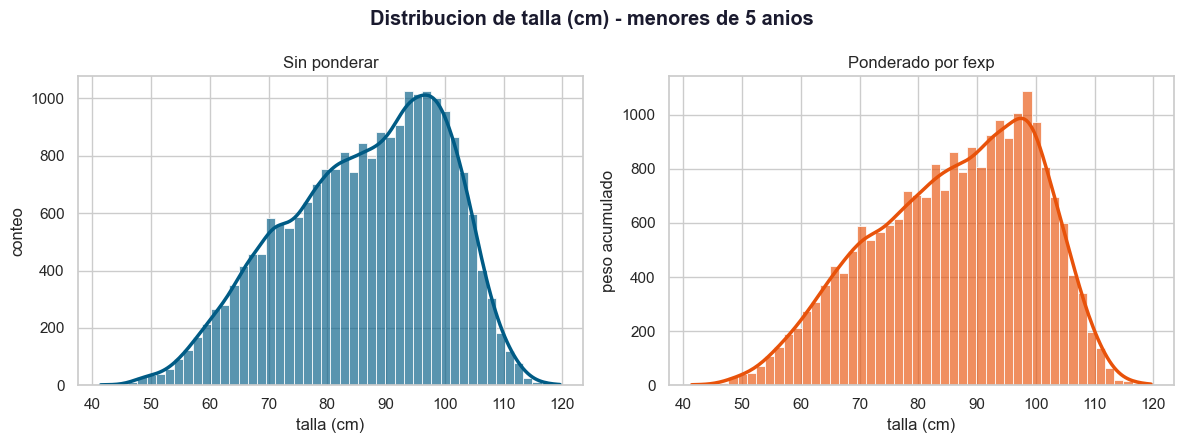

Media sin ponderar:  86.39 cm
Media ponderada:     86.21 cm


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Distribucion de talla (cm) - menores de 5 anios",
             color=DARK, fontweight="bold")

# Sin ponderar
# sns.histplot acepta weights directamente
sns.histplot(
    data=df, x="talla",
    bins=50, kde=True,
    color=AZUL, alpha=0.65,
    line_kws={"lw": 2.5, "color": DARK},
    ax=axes[0]
)
axes[0].set_title("Sin ponderar")
axes[0].set_xlabel("talla (cm)")
axes[0].set_ylabel("conteo")

# Ponderado: se pasa fexp como weights
sns.histplot(
    data=df, x="talla",
    weights="fexp",
    bins=50, kde=True,
    color=NARANJA, alpha=0.65,
    line_kws={"lw": 2.5, "color": DARK},
    ax=axes[1]
)
axes[1].set_title("Ponderado por fexp")
axes[1].set_xlabel("talla (cm)")
axes[1].set_ylabel("peso acumulado")

plt.tight_layout()
plt.show()

# Estadísticas comparadas
print(f"Media sin ponderar:  {df['talla'].mean():.2f} cm")
media_pond = personas.filter(
    pl.col("talla").is_not_null()
    ).select(
        (pl.col("talla")*pl.col("fexp")).sum()/pl.col("fexp").sum()
        ).item()
print(f"Media ponderada:     {media_pond:.2f} cm")

### Ejercicio 1.2: Boxplot y violin - comparación de formatos

El **boxplot** muestra: mínimo, Q1, mediana, Q3, máximo y outliers.
El **violin** agrega la forma de la distribución a ambos lados.

Para estos gráficos seaborn no acepta `weights`, por lo que usamos `df_pond`.

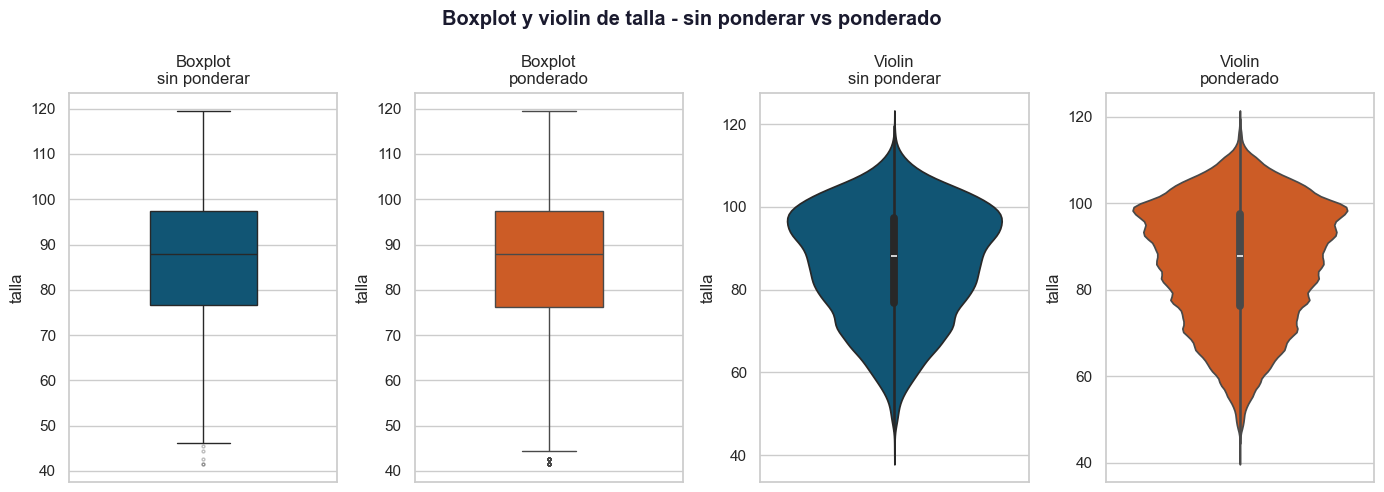

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle("Boxplot y violin de talla - sin ponderar vs ponderado",
             color=DARK, fontweight="bold")

# Boxplot sin ponderar
sns.boxplot(
    data=df, y="talla",
    color=AZUL, width=0.4,
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
    ax=axes[0]
)
axes[0].set_title("Boxplot\nsin ponderar")
axes[0].set_xlabel("")

# Boxplot ponderado
sns.boxplot(
    data=df_pond, y="talla",
    color=NARANJA, width=0.4,
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
    ax=axes[1]
)
axes[1].set_title("Boxplot\nponderado")
axes[1].set_xlabel("")

# Violin sin ponderar
sns.violinplot(
    data=df, y="talla",
    color=AZUL, inner="box",
    ax=axes[2]
)
axes[2].set_title("Violin\nsin ponderar")
axes[2].set_xlabel("")

# Violin ponderado
sns.violinplot(
    data=df_pond, y="talla",
    color=NARANJA, inner="box",
    ax=axes[3]
)
axes[3].set_title("Violin\nponderado")
axes[3].set_xlabel("")

plt.tight_layout()
plt.show()


## Bloque 2: Variable continua por variable categórica

**Variable visual:** color hue para la categoría (variable nominal, asociativa en Roth).
El color hue es apropiado aquí porque no implica orden entre grupos.

### Ejercicio 2.1: Histograma de talla por área

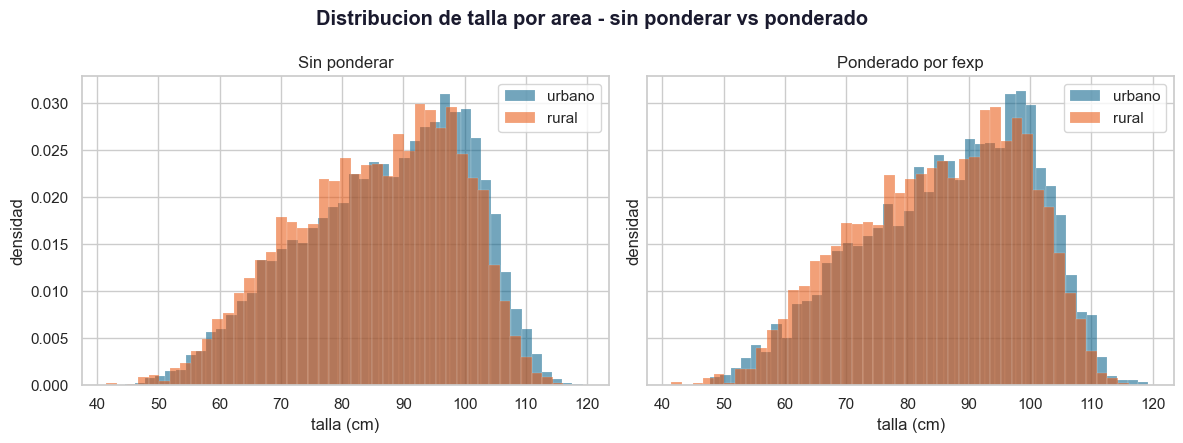

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig.suptitle("Distribucion de talla por area - sin ponderar vs ponderado",color=DARK, fontweight="bold")

# Panel izquierdo: sin ponderar
talla_urbano_sp = df[df["area"] == "urbano"]["talla"].dropna()
talla_rural_sp  = df[df["area"] == "rural"]["talla"].dropna()

axes[0].hist(talla_urbano_sp, bins=45, density=True, alpha=0.55,color=AZUL, label="urbano", edgecolor="white", linewidth=0.2)
axes[0].hist(talla_rural_sp,  bins=45, density=True, alpha=0.55,color=NARANJA, label="rural", edgecolor="white", linewidth=0.2)
axes[0].set_title("Sin ponderar")
axes[0].set_xlabel("talla (cm)")
axes[0].set_ylabel("densidad")
axes[0].legend()

# Panel derecho: ponderado
talla_urbano_pond = df_pond[df_pond["area"] == "urbano"]["talla"].dropna()
talla_rural_pond  = df_pond[df_pond["area"] == "rural"]["talla"].dropna()

axes[1].hist(talla_urbano_pond, bins=45, density=True, alpha=0.55,
             color=AZUL, label="urbano", edgecolor="white", linewidth=0.2)
axes[1].hist(talla_rural_pond,  bins=45, density=True, alpha=0.55,
             color=NARANJA, label="rural", edgecolor="white", linewidth=0.2)
axes[1].set_title("Ponderado por fexp")
axes[1].set_xlabel("talla (cm)")
axes[1].set_ylabel("densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

### Ejercicio 2.2: Violin por grupo - talla por área y por región

El violin permite comparar forma, mediana y dispersión entre grupos en un solo gráfico.
Usamos `df_pond` porque seaborn no acepta `weights` en `violinplot`.

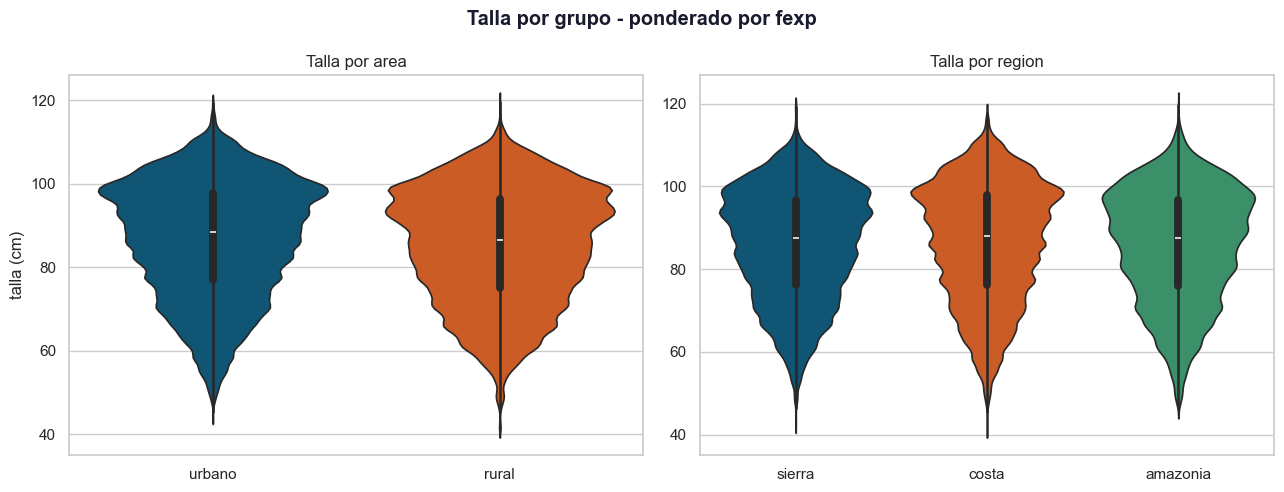

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Talla por grupo - ponderado por fexp",color=DARK, fontweight="bold")

# Por area
sns.violinplot(
    data=df_pond, x="area", y="talla",
    hue="area", palette={"urbano": AZUL, "rural": NARANJA},
    inner="box", legend=False,
    ax=axes[0]
)
axes[0].set_title("Talla por area")
axes[0].set_xlabel("")
axes[0].set_ylabel("talla (cm)")

# Por región
orden_reg = ["sierra", "costa", "amazonia"]
sns.violinplot(
    data=df_pond[df_pond["region"].isin(orden_reg)],
    x="region", y="talla",
    hue="region",
    palette={"sierra": AZUL, "costa": NARANJA, "amazonia": VERDE},
    order=orden_reg,
    inner="box", legend=False,
    ax=axes[1]
)
axes[1].set_title("Talla por region")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Bloque 3: Una variable categórica

**Variable visual:** posición (eje x o y) y longitud de la barra para el valor.
Para variables nominales sin orden natural (como etnia), las barras horizontales son preferibles cuando hay muchas categorías: el eje y tiene más espacio para las etiquetas.

**Nota:** para proporciones ponderadas calculamos manualmente el agregado con Polars antes de graficar.

### Ejercicio 3.1: Prevalencia de desnutrición por quintil - barras ponderadas

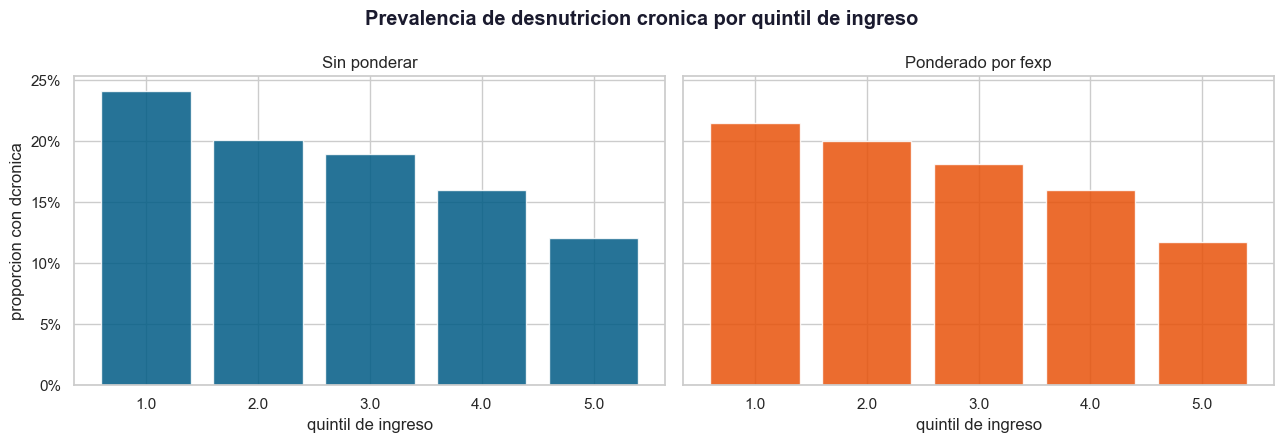

In [64]:
# Cálculo ponderado con Polars
prev_quintil = (
    personas
    .filter(pl.col("quintil").is_not_null() & pl.col("dcronica").is_not_null())
    .group_by("quintil")
    .agg([
        (pl.col("dcronica") * pl.col("fexp")).sum().alias("dc_pond"),
        pl.col("fexp").sum().alias("total_pond"),
    ])
    .with_columns(
        (pl.col("dc_pond") / pl.col("total_pond")).alias("prev")
    )
    .sort("quintil")
    .to_pandas()
)

prev_sp = (
    personas
    .filter(pl.col("quintil").is_not_null() & pl.col("dcronica").is_not_null())
    .group_by("quintil")
    .agg(pl.col("dcronica").mean().alias("prev"))
    .sort("quintil")
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
fig.suptitle("Prevalencia de desnutricion cronica por quintil de ingreso",color=DARK, fontweight="bold")

# Sin ponderar
axes[0].bar(prev_sp["quintil"].astype(str), prev_sp["prev"],color=AZUL, alpha=0.85, edgecolor="white")
axes[0].set_title("Sin ponderar")
axes[0].set_xlabel("quintil de ingreso")
axes[0].set_ylabel("proporcion con dcronica")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Ponderado
axes[1].bar(prev_quintil["quintil"].astype(str), prev_quintil["prev"],color=NARANJA, alpha=0.85, edgecolor="white")
axes[1].set_title("Ponderado por fexp")
axes[1].set_xlabel("quintil de ingreso")
axes[1].set_ylabel("")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

### Ejercicio 3.2: Distribución de etnia - barras horizontales ponderadas

Con muchas categorías las **barras horizontales** son preferibles: las etiquetas del eje y tienen espacio para ser legibles sin rotación.
Ordenamos de mayor a menor proporción para facilitar la comparación (variable visual: posición).

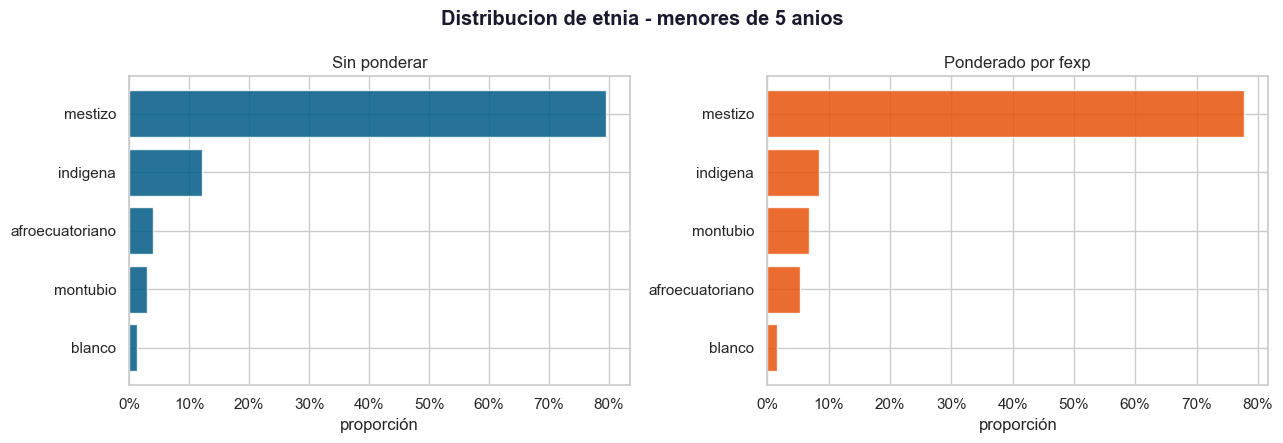

In [65]:
# Cálculo ponderado
# Sin ponderar: conteo simple en Polars
dist_sp = (
    personas
    .filter(pl.col("etnia").is_not_null())
    .group_by("etnia")
    .agg(pl.len().alias("n"))
    .with_columns(
        (pl.col("n") / pl.col("n").sum()).alias("prop")
    )
    .sort("prop", descending=True)
    .to_pandas()
)

# Ponderado: suma de fexp en Polars
dist_etnia = (
    personas
    .filter(pl.col("etnia").is_not_null())
    .group_by("etnia")
    .agg(pl.col("fexp").sum().alias("peso"))
    .with_columns(
        (pl.col("peso") / pl.col("peso").sum()).alias("prop")
    )
    .sort("prop", descending=True)
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Distribucion de etnia - menores de 5 anios",
             color=DARK, fontweight="bold")

axes[0].barh(dist_sp["etnia"], dist_sp["prop"],color=AZUL, alpha=0.85, edgecolor="white")
axes[0].set_title("Sin ponderar")
axes[0].set_xlabel("proporción")
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Ponderado
axes[1].barh(dist_etnia["etnia"], dist_etnia["prop"],color=NARANJA, alpha=0.85, edgecolor="white")
axes[1].set_title("Ponderado por fexp")
axes[1].set_xlabel("proporción")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

## Bloque 4: Dos variables continuas

**Variable visual principal:** posición en x e y (las más efectivas para datos cuantitativos según Roth).

Cuatro formas de explorar la relación talla–edad:
- **Scatter:** cada punto es un niño
- **Regresión lineal:** tendencia global paramétrica
- **Lowess:** tendencia no paramétrica, sigue la curva real de crecimiento
- **Hexbin:** resuelve el solapamiento cuando hay miles de puntos

### Ejercicio 4.1: Scatter - talla vs edad en días

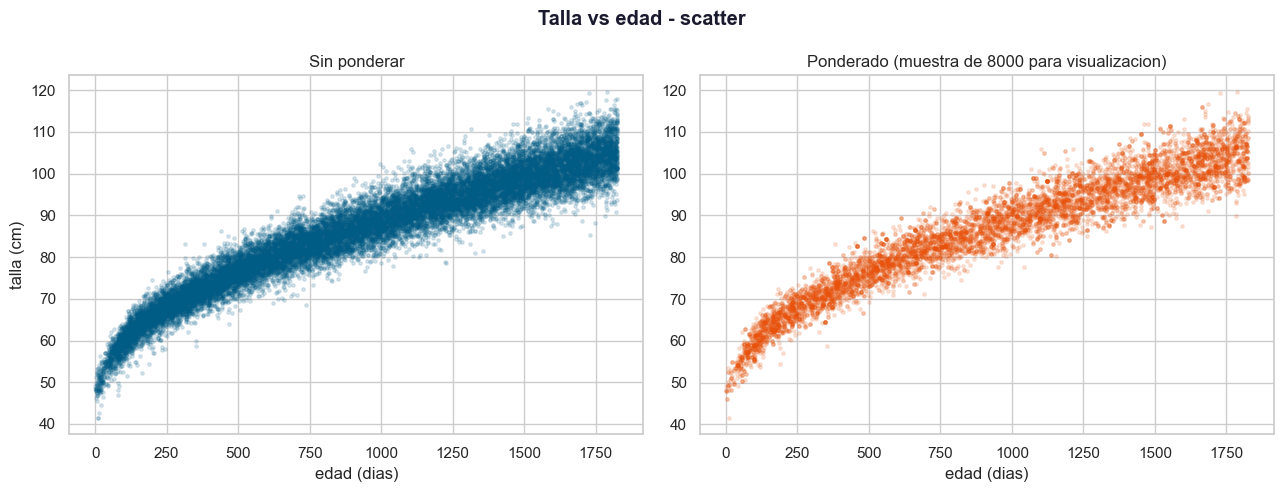

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Talla vs edad - scatter", color=DARK, fontweight="bold")

# Sin ponderar
axes[0].scatter(
    df["edaddias"], df["talla"],
    color=AZUL, alpha=0.15, s=6, rasterized=True
)
axes[0].set_title("Sin ponderar")
axes[0].set_xlabel("edad (dias)")
axes[0].set_ylabel("talla (cm)")

# Ponderado: muestra aleatoria del df_pond para no saturar
muestra_pond = df_pond.sample(n=8000, random_state=123)
axes[1].scatter(
    muestra_pond["edaddias"], muestra_pond["talla"],
    color=NARANJA, alpha=0.15, s=6, rasterized=True
)
axes[1].set_title("Ponderado (muestra de 8000 para visualizacion)")
axes[1].set_xlabel("edad (dias)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Ejercicio 4.2: Regresión lineal y lowess

- **Regresión lineal** (`np.polyfit`): asume que la relación es lineal. Útil como resumen pero puede ser engañosa si la curva de crecimiento no es lineal.
- **Lowess** (`statsmodels`): no asume ninguna forma funcional. Sigue la tendencia real.

Para lowess ponderado usamos `df_pond` (que ya lleva los pesos incorporados en la frecuencia de filas).

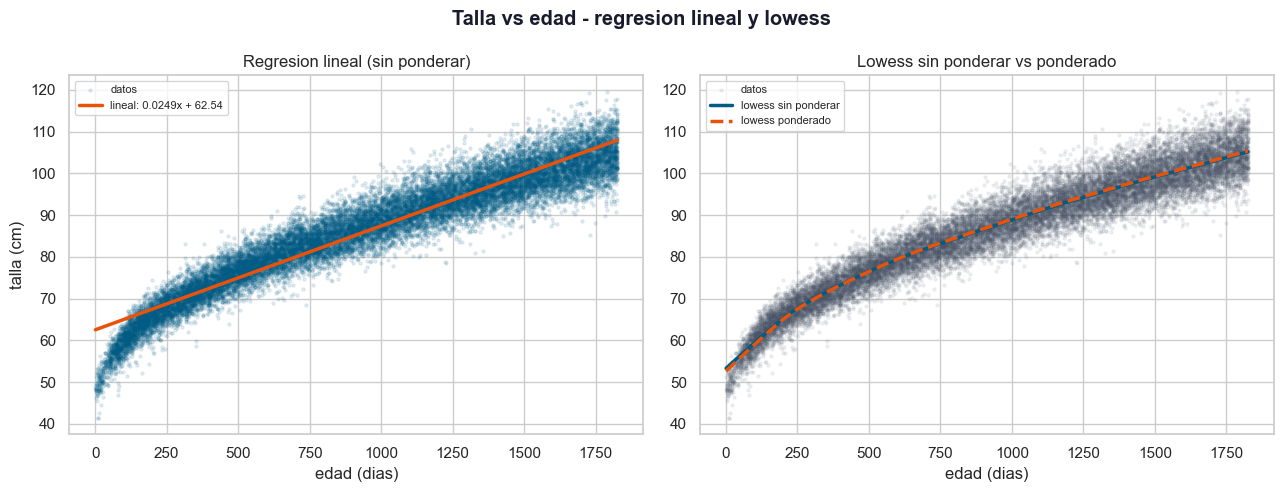

In [67]:
sub = personas.select(["edaddias", "talla"]).drop_nulls().to_pandas()
sub_pond = df_pond.dropna(subset=["edaddias", "talla"])

# Regresión lineal
coef = np.polyfit(sub["edaddias"], sub["talla"], deg=1)
x_lin = np.linspace(sub["edaddias"].min(), sub["edaddias"].max(), 300)
y_lin = np.polyval(coef, x_lin)

# Lowess sin ponderar
lw_sp = lowess(sub["talla"], sub["edaddias"], frac=0.2, return_sorted=True)

# Lowess ponderado (vía df_pond)
lw_pond = lowess(sub_pond["talla"], sub_pond["edaddias"], frac=0.2, return_sorted=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Talla vs edad - regresion lineal y lowess",color=DARK, fontweight="bold")

# Panel izquierdo: regresión lineal
axes[0].scatter(sub["edaddias"], sub["talla"],color=AZUL, alpha=0.10, s=5, rasterized=True, label="datos")
axes[0].plot(x_lin, y_lin, color=NARANJA, lw=2.5,label=f"lineal: {coef[0]:.4f}x + {coef[1]:.2f}")
axes[0].set_title("Regresion lineal (sin ponderar)")
axes[0].set_xlabel("edad (dias)")
axes[0].set_ylabel("talla (cm)")
axes[0].legend(fontsize=8)

# Panel derecho: lowess sin ponderar vs ponderado
axes[1].scatter(sub["edaddias"], sub["talla"],color=MID, alpha=0.08, s=5, rasterized=True, label="datos")
axes[1].plot(lw_sp[:, 0],   lw_sp[:, 1],   color=AZUL,   lw=2.5,label="lowess sin ponderar")
axes[1].plot(lw_pond[:, 0], lw_pond[:, 1], color=NARANJA, lw=2.5, ls="--",label="lowess ponderado")
axes[1].set_title("Lowess sin ponderar vs ponderado")
axes[1].set_xlabel("edad (dias)")
axes[1].set_ylabel("")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Ejercicio 4.3: Hexbin - resolviendo el solapamiento

Con más de 20 000 puntos el scatter es ilegible por solapamiento. El **hexbin** divide el plano en celdas hexagonales y colorea cada celda según cuántos puntos caen en ella.

**Variable visual:** color value (intensidad) para representar densidad - ordenada y cuantitativa según Roth.

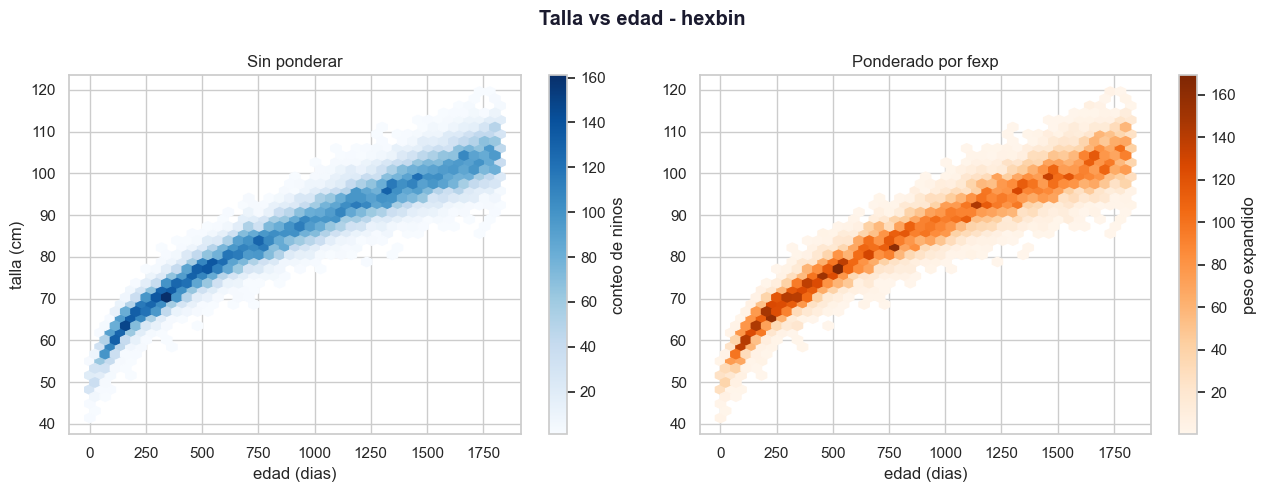

In [68]:
sub = (
    personas
    .select(["edaddias", "talla"])
    .drop_nulls()
    .to_pandas()
)

sub_w = (
    personas
    .select(["edaddias", "talla", "fexp"])
    .drop_nulls()
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Talla vs edad - hexbin", color=DARK, fontweight="bold")

# Sin ponderar
hb1 = axes[0].hexbin(
    sub["edaddias"], sub["talla"],
    gridsize=40, cmap="Blues", mincnt=1
)
plt.colorbar(hb1, ax=axes[0], label="conteo de ninos")
axes[0].set_title("Sin ponderar")
axes[0].set_xlabel("edad (dias)")
axes[0].set_ylabel("talla (cm)")

# Ponderado: se pasa fexp como C (valor por punto) y reduce_C_function=np.sum
hb2 = axes[1].hexbin(
    sub_w["edaddias"], sub_w["talla"],
    C=sub_w["fexp"],
    reduce_C_function=np.sum,
    gridsize=40, cmap="Oranges", mincnt=1
)
plt.colorbar(hb2, ax=axes[1], label="peso expandido")
axes[1].set_title("Ponderado por fexp")
axes[1].set_xlabel("edad (dias)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

---
## Bloque 5: Multivariado - combinando variables visuales

Agregamos dimensiones al scatter básico usando las variables visuales de Roth:

| Canal visual | Variable | Tipo en Roth | Por qué es apropiado |
|---|---|---|---|
| Posición x | `edaddias` | cuantitativa | máxima precisión perceptual |
| Posición y | `talla` | cuantitativa | máxima precisión perceptual |
| Color hue | `sexo` | nominal, asociativa | no implica orden entre categorías |
| Size | `quintil` | ordinal | tamaños mayores percibidos como "más" |
| Alpha | `dcronica` | nominal binaria | opaco = caso presente (sube a figura) |

Usamos `df_pond` para que la densidad visual refleje la distribución poblacional.

### Ejercicio 5.1: Scatter multivariado ponderado

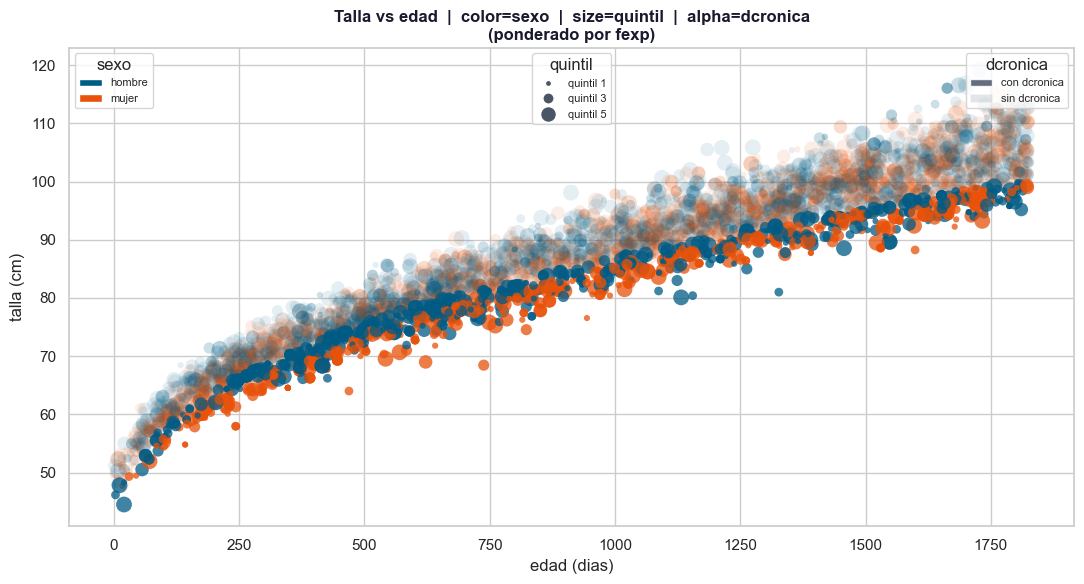

In [69]:
sub = df_pond.dropna(subset=["edaddias", "talla", "sexo", "quintil", "dcronica"]).copy()

# Muestra para no saturar el gráfico
sub = sub.sample(n=6000, random_state=123)

# Mapeos de variables visuales
color_map  = {"hombre": AZUL, "mujer": NARANJA}
size_map   = {1: 20, 2: 40, 3: 65, 4: 95, 5: 130}   # size proporcional al quintil
alpha_map  = {0.0: 0.12, 1.0: 0.85}                  # dcronica=1 opaco, =0 transparente

colores = sub["sexo"].map(color_map)
tamanios = sub["quintil"].map(size_map)
alphas   = sub["dcronica"].map(alpha_map)

fig, ax = plt.subplots(figsize=(11, 6))

# Primero los sin desnutrición (alpha bajo, van al fondo)
mask_no = sub["dcronica"] == 0.0
ax.scatter(
    sub.loc[mask_no, "edaddias"],
    sub.loc[mask_no, "talla"],
    c=colores[mask_no],
    s=tamanios[mask_no],
    alpha=0.10,
    edgecolors="none",
    rasterized=True
)

# Luego los con desnutrición (alpha alto, suben a figura)
mask_si = sub["dcronica"] == 1.0
ax.scatter(
    sub.loc[mask_si, "edaddias"],
    sub.loc[mask_si, "talla"],
    c=colores[mask_si],
    s=tamanios[mask_si],
    alpha=0.75,
    edgecolors="none",
    rasterized=True
)

# Leyendas manuales
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

leyenda_color = [
    Patch(facecolor=AZUL,   label="hombre"),
    Patch(facecolor=NARANJA, label="mujer"),
]
leyenda_size = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=MID,
           markersize=np.sqrt(size_map[q]), label=f"quintil {q}")
    for q in [1, 3, 5]
]
leyenda_alpha = [
    Patch(facecolor=MID, alpha=0.85, label="con dcronica"),
    Patch(facecolor=MID, alpha=0.15, label="sin dcronica"),
]

leg1 = ax.legend(handles=leyenda_color, title="sexo",loc="upper left", fontsize=8)
leg2 = ax.legend(handles=leyenda_size, title="quintil",loc="upper center", fontsize=8)
leg3 = ax.legend(handles=leyenda_alpha, title="dcronica",loc="upper right", fontsize=8)
ax.add_artist(leg1)
ax.add_artist(leg2)

ax.set_title("Talla vs edad  |  color=sexo  |  size=quintil  |  alpha=dcronica\n(ponderado por fexp)",color=DARK, fontweight="bold")
ax.set_xlabel("edad (dias)")
ax.set_ylabel("talla (cm)")

plt.tight_layout()
plt.show()

### Ejercicio 5.2: Lowess por grupo con color hue

Una extensión natural del scatter multivariado: agregar una curva lowess **por grupo** para ver si las trayectorias de crecimiento difieren entre hombres y mujeres.

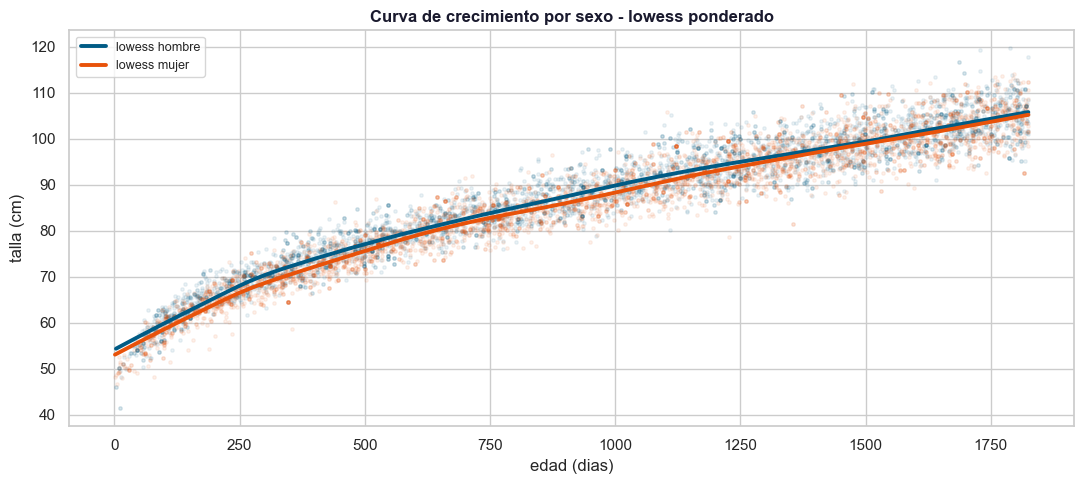

In [70]:
sub = df_pond.dropna(subset=["edaddias", "talla", "sexo"]).copy()

fig, ax = plt.subplots(figsize=(11, 5))

for sexo, color in [("hombre", AZUL), ("mujer", NARANJA)]:
    grupo = sub[sub["sexo"] == sexo].sample(n=4000, random_state=123)

    # Puntos
    ax.scatter(grupo["edaddias"], grupo["talla"],color=color, alpha=0.08, s=6, rasterized=True)

    # Lowess ponderado
    lw = lowess(grupo["talla"].values,grupo["edaddias"].values,frac=0.25, return_sorted=True)
    ax.plot(lw[:, 0], lw[:, 1], color=color, lw=2.8, label=f"lowess {sexo}")

ax.set_title("Curva de crecimiento por sexo - lowess ponderado",color=DARK, fontweight="bold")
ax.set_xlabel("edad (dias)")
ax.set_ylabel("talla (cm)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()